In [19]:
import pandas as pd
df = pd.read_csv("startup_failure_prediction.csv")

In [20]:
df.head()

,Startup_Name,Industry,Startup_Age,Funding_Amount,Number_of_Founders,Founder_Experience,Employees_Count,Revenue,Burn_Rate,Market_Size,Business_Model,Product_Uniqueness_Score,Customer_Retention_Rate,Marketing_Expense,Startup_Status
0,Startup_1,Logistics,8,18328419,2,13,581,97866143,602731,Medium,B2B,2,79.61,987830,1
1,Startup_2,Education,3,39753708,3,16,529,36868744,820698,Large,B2C,3,32.47,599615,1
2,Startup_3,Healthcare,14,18073294,1,28,82,3478737,992205,Small,B2C,1,9.88,780730,1
3,Startup_4,E-commerce,5,19435653,4,14,234,80716899,536747,Medium,B2C,9,23.20,188588,1
4,Startup_5,Finance,14,4205797,4,17,960,53347246,555199,Medium,Hybrid,3,73.52,310892,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Startup_Name              5000 non-null   object 
 1   Industry                  5000 non-null   object 
 2   Startup_Age               5000 non-null   int64  
 3   Funding_Amount            5000 non-null   int64  
 4   Number_of_Founders        5000 non-null   int64  
 5   Founder_Experience        5000 non-null   int64  
 6   Employees_Count           5000 non-null   int64  
 7   Revenue                   5000 non-null   int64  
 8   Burn_Rate                 5000 non-null   int64  
 9   Market_Size               5000 non-null   object 
 10  Business_Model            5000 non-null   object 
 11  Product_Uniqueness_Score  5000 non-null   int64  
 12  Customer_Retention_Rate   5000 non-null   float64
 13  Marketing_Expense         5000 non-null   int64  
 14  Startup_

In [22]:
df.isna().sum()

Startup_Name                0
Industry                    0
Startup_Age                 0
Funding_Amount              0
Number_of_Founders          0
Founder_Experience          0
Employees_Count             0
Revenue                     0
Burn_Rate                   0
Market_Size                 0
Business_Model              0
Product_Uniqueness_Score    0
Customer_Retention_Rate     0
Marketing_Expense           0
Startup_Status              0
dtype: int64

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
def find_outliers(df,col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.boxplot(df[col])
    plt.subplot(1,2,2)
    mean4=df[col].mean()
    std4=df[col].std() 
    sns.histplot(data=df , x=col , kde=True)
    plt.axvline(mean4,color="red")
    plt.axvline(mean4+3*std4 , color = "blue")
    plt.axvline(mean4-3*std4 , color="blue")

In [25]:
def show_outliers(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr = q3-q1
    upper = q3+(1.5*iqr)
    lower=q1-(1.5*iqr)
    return df[(df[col]<lower) | (df[col]>upper)]

In [26]:
def handleOutliers(df,col):
    q1=df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr=q3-q1
    lower = q1-(1.5*iqr)
    upper = q3+(1.5*iqr)
    df.loc[df[col]>upper , col]=upper
    df.loc[df[col]<lower , col]=lower

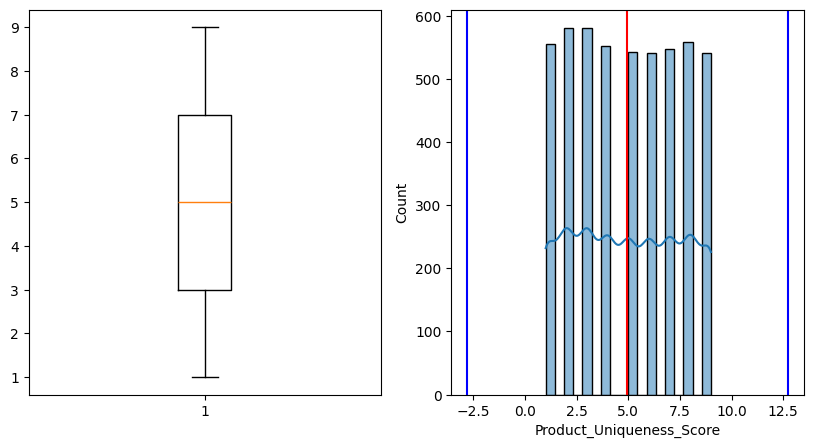

In [36]:
find_outliers(df,"Product_Uniqueness_Score")

In [37]:
df.head()

,Startup_Name,Industry,Startup_Age,Funding_Amount,Number_of_Founders,Founder_Experience,Employees_Count,Revenue,Burn_Rate,Market_Size,Business_Model,Product_Uniqueness_Score,Customer_Retention_Rate,Marketing_Expense,Startup_Status
0,Startup_1,Logistics,8,18328419,2,13,581,97866143,602731,Medium,B2B,2,79.61,987830,1
1,Startup_2,Education,3,39753708,3,16,529,36868744,820698,Large,B2C,3,32.47,599615,1
2,Startup_3,Healthcare,14,18073294,1,28,82,3478737,992205,Small,B2C,1,9.88,780730,1
3,Startup_4,E-commerce,5,19435653,4,14,234,80716899,536747,Medium,B2C,9,23.20,188588,1
4,Startup_5,Finance,14,4205797,4,17,960,53347246,555199,Medium,Hybrid,3,73.52,310892,1


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Startup_Name              5000 non-null   object 
 1   Industry                  5000 non-null   object 
 2   Startup_Age               5000 non-null   int64  
 3   Funding_Amount            5000 non-null   int64  
 4   Number_of_Founders        5000 non-null   int64  
 5   Founder_Experience        5000 non-null   int64  
 6   Employees_Count           5000 non-null   int64  
 7   Revenue                   5000 non-null   int64  
 8   Burn_Rate                 5000 non-null   int64  
 9   Market_Size               5000 non-null   object 
 10  Business_Model            5000 non-null   object 
 11  Product_Uniqueness_Score  5000 non-null   int64  
 12  Customer_Retention_Rate   5000 non-null   float64
 13  Marketing_Expense         5000 non-null   int64  
 14  Startup_

In [40]:
df["Startup_Name"].unique()

array(['Startup_1', 'Startup_2', 'Startup_3', ..., 'Startup_4998',
       'Startup_4999', 'Startup_5000'], shape=(5000,), dtype=object)

In [41]:
df["Industry"].value_counts()

Industry
AI/ML         743
Education     741
Tech          723
Healthcare    722
Logistics     721
E-commerce    678
Finance       672
Name: count, dtype: int64

In [43]:
df["Business_Model"].value_counts()

Business_Model
B2B       1690
Hybrid    1659
B2C       1651
Name: count, dtype: int64